# Section1: Problem Definition & Target User

## Problem Definition
### Core Pain Points
1.  **Critical flaws in single-factor equity strategies**: Standalone price momentum strategies suffer from severe crash risk and extreme drawdowns during market reversals, while pure high-dividend investing is vulnerable to "dividend value traps"—artificially inflated yields driven by collapsing share prices, rather than sustainable corporate fundamentals. Entry-level practitioners lack a simple, balanced framework to mitigate these flaws.
2.  **Steep barrier to entry for academic quantitative finance learning**: For finance and accounting students, WRDS-based empirical research has a high learning curve, including complex cross-database merging of CRSP and Compustat datasets, and high risk of fatal academic errors such as look-ahead bias. There is a lack of out-of-the-box, academically compliant project templates for both coursework and teaching.

### How This Product Solves These Problems
This data product delivers a complete, ready-to-use solution that directly addresses the above pain points:
1.  **Balanced dual-factor screening framework**: It combines 12-month price momentum and high dividend yield factors, using trend momentum to capture upside return potential and dividend yield to provide a fundamental downside safety net, effectively offsetting the inherent flaws of single-factor strategies.
2.  **Reproducible, bias-mitigated WRDS project template**: It provides a full end-to-end workflow with built-in guardrails against common academic biases, standardized code structure, and out-of-the-box usability, drastically lowering the entry barrier for students, instructors, and entry-level learners to complete rigorous, reproducible quantitative finance research.
## Target User
- Finance and accounting students completing WRDS-related course assignments and projects
- Quantitative finance course instructors using the project as a standardized, reproducible teaching demo
- Entry-level learners building their first academically compliant quantitative stock selection strategy

# Section2: Data Loading 

In [79]:
from __future__ import annotations

In [80]:
import argparse
import json
import os
from dataclasses import dataclass
from pathlib import Path

In [81]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv
import wrds

In [82]:
"""
Core Objective:
Identify stocks with upward price momentum and high dividend yield within a specified time window,
and output tables and charts to form a complete small-scale course project.
"""

'\nCore Objective:\nIdentify stocks with upward price momentum and high dividend yield within a specified time window,\nand output tables and charts to form a complete small-scale course project.\n'

In [83]:
@dataclass
class StrategyConfig:
    start_date: str = "2020-01-01"
    end_date: str = "2024-12-31"

    momentum_window: int = 12

    min_momentum: float = 0.0

   
    dividend_quantile: float = 0.7

   
    report_lag_months: int = 6

   
    min_price: float = 5.0

  
    dividend_field: str | None = None

   
    top_n: int = 20

   
    momentum_weight: float = 0.5
    dividend_weight: float = 0.5

    
    out_dir: str = "output_teaching"

In [84]:
from pathlib import Path
def ensure_dir(path: str | Path) -> Path:
    p = Path(path)
    p.mkdir(parents=True, exist_ok=True)
    return p

In [85]:
def to_month_end(series: pd.Series) -> pd.Series:
    return pd.to_datetime(series) + pd.offsets.MonthEnd(0)

In [86]:
def winsorize_series(series: pd.Series, lower: float = 0.01, upper: float = 0.99) -> pd.Series:
    """Apply simple winsorization to extreme values to prevent outliers from excessively distorting the distribution."""
    valid = series.dropna()
    if valid.empty:
        return series
    low_value = valid.quantile(lower)
    high_value = valid.quantile(upper)
    return series.clip(lower=low_value, upper=high_value)

In [87]:
def annualized_return(monthly_returns: pd.Series) -> float:
    """Annualize monthly returns."""
    r = monthly_returns.dropna()
    if r.empty:
        return float("nan")
    cumulative = (1.0 + r).prod()
    years = len(r) / 12.0
    if years <= 0 or cumulative <= 0:
        return float("nan")
    return float(cumulative ** (1.0 / years) - 1.0)

In [88]:
def annualized_vol(monthly_returns: pd.Series) -> float:
    """Annualize monthly volatility to annualized volatility."""
    r = monthly_returns.dropna()
    if len(r) < 2:
        return float("nan")
    return float(r.std(ddof=1) * np.sqrt(12))

In [89]:
def annualized_sharpe(monthly_returns: pd.Series) -> float:
    """Simply calculate the annualized Sharpe ratio,a higher ratio indicates a higher return per unit of risk."""
    r = monthly_returns.dropna()
    if len(r) < 2:
        return float("nan")
    vol = r.std(ddof=1)
    if np.isclose(vol, 0.0):
        return float("nan")
    return float((r.mean() / vol) * np.sqrt(12))

In [90]:
def max_drawdown(cumulative_curve: pd.Series) -> float:
    """Maximum Drawdown:Measures the deepest drawdown amplitude of the strategy throughout its history"""
    c = cumulative_curve.dropna()
    if c.empty:
        return float("nan")
    running_max = c.cummax()
    drawdown = c / running_max - 1.0
    return float(drawdown.min())

In [91]:
def write_json(obj: dict, path: str | Path) -> None:
    """Save Python dictionary to JSON file."""
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2, default=str)

# Section 3 : Data Cleaning and Preparation 

In [92]:
def get_connection():
    load_dotenv()
    username = os.getenv("WRDS_USERNAME")
    if username:
        return wrds.Connection(wrds_username=username)
    return wrds.Connection()

In [93]:
DIVIDEND_FIELD_CANDIDATES = [
    "dvpsx_f",  # One of the common fields for dividend per share
    "dvpsx_c",  # One of the common earnings per share dividend fields
    "dvc",      # It may refer to the total dividend of common shares, which usually needs to be converted in conjunction with csho.
    "dvpa",     # It may also be a per-share dividend field
]

In [94]:
def get_comp_funda_columns(conn) -> list[str]:
    """Check what fields are in the comp.funda table."""
    try:
        desc = conn.describe_table(library="comp", table="funda")
        if isinstance(desc, pd.DataFrame) and "name" in desc.columns:
            return desc["name"].astype(str).tolist()
    except Exception:
        pass
    return []

In [95]:
def resolve_dividend_field(conn, preferred: str | None = None) -> str:
   
    columns = get_comp_funda_columns(conn)

    if preferred:
        if preferred not in columns:
            raise ValueError(
                f"The specified dividend field you entered {preferred!r} does not exist in comp.funda.\n"
                f"Current available candidate fields:{[c for c in DIVIDEND_FIELD_CANDIDATES if c in columns]}"
            )
        return preferred

    for field in DIVIDEND_FIELD_CANDIDATES:
        if field in columns:
            return field

    raise ValueError(
        "No supported dividend fields found.\n"
        f"Check completed：{DIVIDEND_FIELD_CANDIDATES}"
    )

In [96]:
def get_crsp_monthly(conn, start_date: str, end_date: str) -> pd.DataFrame:
    sql = f"""
    select
        a.permno,
        a.date,
        a.ret,
        a.prc,
        a.shrout,
        b.exchcd,
        b.shrcd,
        b.ticker,
        b.comnam
    from crsp.msf a
    left join crsp.msenames b
      on a.permno = b.permno
     and a.date between b.namedt and b.nameendt
    where a.date between '{start_date}' and '{end_date}'
      and b.shrcd in (10, 11)
      and b.exchcd in (1, 2, 3)
    order by a.permno, a.date
    """
    df = conn.raw_sql(sql, date_cols=["date"])
    if df.empty:
        return df

    # The prc field in CRSP may carry a negative sign, and its absolute value is more suitable for use as the price.
    df["prc"] = pd.to_numeric(df["prc"], errors="coerce").abs()
    df["ret"] = pd.to_numeric(df["ret"], errors="coerce")
    df["shrout"] = pd.to_numeric(df["shrout"], errors="coerce")
    df["date"] = to_month_end(df["date"])
    return df

In [97]:
def get_compustat_dividends(
    conn,
    start_date: str,
    end_date: str,
    dividend_field: str,
) -> pd.DataFrame:
    sql = f"""
    select
        gvkey,
        datadate,
        fyear,
        fyr,
        tic,
        conm,
        csho,
        {dividend_field} as dividend_raw,
        at,
        sale
    from comp.funda
    where datadate between '{start_date}' and '{end_date}'
      and indfmt = 'INDL'
      and datafmt = 'STD'
      and popsrc = 'D'
      and consol = 'C'
    order by gvkey, datadate
    """
    df = conn.raw_sql(sql, date_cols=["datadate"])
    if df.empty:
        return df

    df["dividend_raw"] = pd.to_numeric(df["dividend_raw"], errors="coerce")
    df["csho"] = pd.to_numeric(df["csho"], errors="coerce")
    df["dividend_field_used"] = dividend_field
    return df

In [98]:
def infer_dividend_per_share(df: pd.DataFrame, dividend_field: str) -> pd.DataFrame:
    out = df.copy()

    if dividend_field in {"dvpsx_f", "dvpsx_c", "dvpa"}:
        out["annual_div_ps"] = out["dividend_raw"]
    elif dividend_field == "dvc":
        raw = out["dividend_raw"]
        csho = out["csho"].replace({0: pd.NA})
        per_share_guess = raw / csho

        
        out["annual_div_ps"] = raw.where(raw.abs() <= 10, per_share_guess)
    else:
        out["annual_div_ps"] = out["dividend_raw"]

    return out

In [99]:
def get_ccm_link(conn) -> pd.DataFrame:
    sql = """
    select
        gvkey,
        lpermno as permno,
        linktype,
        linkprim,
        linkdt,
        linkenddt
    from crsp.ccmxpf_linktable
    where lpermno is not null
      and linktype in ('LC', 'LU')
      and linkprim in ('P', 'C')
    """
    return conn.raw_sql(sql, date_cols=["linkdt", "linkenddt"])

In [100]:
def merge_ccm(comp_df: pd.DataFrame, ccm_df: pd.DataFrame) -> pd.DataFrame:
    """
    Only retain data within the link validity period to prevent incorrect company-stock mappings.
    """
    if comp_df.empty or ccm_df.empty:
        return pd.DataFrame()

    merged = comp_df.merge(ccm_df, on="gvkey", how="inner")
    merged["linkenddt"] = merged["linkenddt"].fillna(pd.Timestamp("today").normalize())

    merged = merged[
        (merged["datadate"] >= merged["linkdt"])
        & (merged["datadate"] <= merged["linkenddt"])
    ].copy()

    
    merged = merged.sort_values(["permno", "datadate", "linkprim", "linktype"])
    merged = merged.drop_duplicates(subset=["permno", "datadate"], keep="first")
    return merged

In [101]:
def build_momentum_signal(crsp_df: pd.DataFrame, momentum_window: int) -> pd.DataFrame:
    if crsp_df.empty:
        return pd.DataFrame()

    df = crsp_df.copy().sort_values(["permno", "date"])
    df["gross_ret"] = 1.0 + df["ret"].fillna(0.0)

    momentum = (
        df.groupby("permno")["gross_ret"]
        .rolling(momentum_window, min_periods=max(3, momentum_window - 2))
        .apply(np.prod, raw=True)
        .reset_index(level=0, drop=True)
        - 1.0
    )

    df[f"mom_{momentum_window}m"] = momentum
    return df

In [102]:
def build_dividend_yield_signal(
    comp_linked_df: pd.DataFrame,
    crsp_df: pd.DataFrame,
    report_lag_months: int,
) -> pd.DataFrame:
    if comp_linked_df.empty or crsp_df.empty:
        return pd.DataFrame(columns=["permno", "date", "annual_div_ps", "dividend_yield"])

    comp = comp_linked_df.copy()
    comp["signal_date"] = pd.to_datetime(comp["datadate"]) + pd.offsets.MonthEnd(report_lag_months)
    comp["signal_date"] = to_month_end(comp["signal_date"])
    comp = comp[["permno", "signal_date", "annual_div_ps", "dividend_field_used"]].dropna(subset=["annual_div_ps"])
    comp = comp.sort_values(["permno", "signal_date"]).drop_duplicates(["permno", "signal_date"], keep="last")

    price_df = crsp_df[["permno", "date", "prc"]].copy()
    price_df["date"] = to_month_end(price_df["date"])
    price_df = price_df.sort_values(["permno", "date"])

    out = price_df.merge(
        comp,
        left_on=["permno", "date"],
        right_on=["permno", "signal_date"],
        how="left",
    )
    out = out.sort_values(["permno", "date"])

    # Carry forward the latest available dividend data after each financial statement filing to avoid look-ahead bias
    out["annual_div_ps"] = out.groupby("permno")["annual_div_ps"].ffill()
    out["dividend_field_used"] = out.groupby("permno")["dividend_field_used"].ffill()

    out["dividend_yield"] = out["annual_div_ps"] / out["prc"]

    # Winsorizing extreme high dividend yields to mitigate outlier impact on cross-sectional ranking
    out["dividend_yield"] = out.groupby("date")["dividend_yield"].transform(
        lambda s: winsorize_series(s, 0.01, 0.99)
    )

    return out[["permno", "date", "annual_div_ps", "dividend_field_used", "dividend_yield"]]

## Section 4 ：Analysis Data

In [54]:
def build_monthly_screener(
    momentum_df: pd.DataFrame,
    dividend_df: pd.DataFrame,
    momentum_window: int,
    min_momentum: float,
    dividend_quantile: float,
    min_price: float,
    top_n: int,
    momentum_weight: float,
    dividend_weight: float,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    if momentum_df.empty or dividend_df.empty:
        return pd.DataFrame(), pd.DataFrame()

    if top_n <= 0:
        raise ValueError("top_n must be a positive integer.")

    weight_sum = momentum_weight + dividend_weight
    if weight_sum <= 0:
        raise ValueError("The sum of momentum_weight and dividend_weight must be greater than 0.")

    mom_col = f"mom_{momentum_window}m"

    df = momentum_df.merge(dividend_df, on=["permno", "date"], how="left")
    df = df[df["prc"] >= min_price].copy()
    df = df[df[mom_col].notna() & df["dividend_yield"].notna()].copy()

    if df.empty:
        return pd.DataFrame(), pd.DataFrame()

    # Rank separately each month: this is a cross-sectional comparison, not a forced comparison of absolute values across different time points
    df["mom_score"] = df.groupby("date")[mom_col].rank(method="average", pct=True)
    df["div_score"] = df.groupby("date")["dividend_yield"].rank(method="average", pct=True)

    df["dividend_cutoff"] = df.groupby("date")["div_score"].transform(lambda s: s.quantile(dividend_quantile))

    # Two core boolean conditions:
    # 1) Price increase: momentum is above the minimum threshold.
    # 2) High dividend yield: dividend yield score is above the monthly threshold.
    df["is_price_up"] = df[mom_col] > min_momentum
    df["is_high_dividend"] = df["div_score"] >= df["dividend_cutoff"]
    df["passes_screen"] = df["is_price_up"] & df["is_high_dividend"]

    df["combined_score"] = (
        df["mom_score"] * momentum_weight + df["div_score"] * dividend_weight
    ) / weight_sum

    # Retain stocks that meet both conditions simultaneously, then select the Top N from them.
    ranked = df.sort_values(["date", "combined_score"], ascending=[True, False]).copy()
    screened = ranked[ranked["passes_screen"]].copy()
    screened["screen_rank"] = screened.groupby("date")["combined_score"].rank(method="first", ascending=False)
    screened = screened[screened["screen_rank"] <= top_n].copy()

    ranked = ranked[
        [
            "permno", "date", "ticker", "comnam", "prc", "ret",
            mom_col, "annual_div_ps", "dividend_field_used", "dividend_yield",
            "mom_score", "div_score", "combined_score",
            "is_price_up", "is_high_dividend", "passes_screen"
        ]
    ]

    screened = screened[
        [
            "permno", "date", "ticker", "comnam", "prc", "ret",
            mom_col, "annual_div_ps", "dividend_field_used", "dividend_yield",
            "mom_score", "div_score", "combined_score",
            "is_price_up", "is_high_dividend", "passes_screen", "screen_rank"
        ]
    ].sort_values(["date", "screen_rank"])

    return ranked, screened

In [45]:
def prepare_future_returns(crsp_df: pd.DataFrame) -> pd.DataFrame:
    future_ret = crsp_df[["permno", "date", "ret"]].copy().sort_values(["permno", "date"])
    future_ret["next_ret"] = future_ret.groupby("permno")["ret"].shift(-1)
    return future_ret[["permno", "date", "next_ret"]]

In [46]:
def backtest_equal_weight(screened_df: pd.DataFrame, crsp_df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    if screened_df.empty or crsp_df.empty:
        empty = pd.DataFrame()
        return empty, empty, empty

    future_ret = prepare_future_returns(crsp_df)

    holdings = screened_df.merge(
        future_ret,
        on=["permno", "date"],
        how="left",
    )

    monthly = holdings.groupby("date", as_index=False).agg(
        portfolio_ret=("next_ret", "mean"),
        n_stocks=("permno", "nunique"),
        avg_dividend_yield=("dividend_yield", "mean"),
        avg_combined_score=("combined_score", "mean"),
    )
    monthly["cumret"] = (1.0 + monthly["portfolio_ret"].fillna(0.0)).cumprod()

    summary = pd.DataFrame([
        {
            "metric": "months",
            "value": int(monthly["portfolio_ret"].notna().sum()),
        },
        {
            "metric": "avg_monthly_return",
            "value": float(monthly["portfolio_ret"].mean()),
        },
        {
            "metric": "annualized_return",
            "value": annualized_return(monthly["portfolio_ret"]),
        },
        {
            "metric": "annualized_vol",
            "value": annualized_vol(monthly["portfolio_ret"]),
        },
        {
            "metric": "annualized_sharpe",
            "value": annualized_sharpe(monthly["portfolio_ret"]),
        },
        {
            "metric": "max_drawdown",
            "value": max_drawdown(monthly["cumret"]),
        },
        {
            "metric": "final_cumulative_return",
            "value": float(monthly["cumret"].iloc[-1] - 1.0) if not monthly.empty else np.nan,
        },
        {
            "metric": "avg_n_stocks",
            "value": float(monthly["n_stocks"].mean()) if not monthly.empty else np.nan,
        },
    ])

    return holdings, monthly, summary

In [47]:
def save_cumulative_return_plot(monthly_df: pd.DataFrame, out_path: str) -> None:
    """Plot strategy cumulative returns curve."""
    if monthly_df.empty:
        return

    plt.figure(figsize=(10, 5))
    plt.plot(monthly_df["date"], monthly_df["cumret"])
    plt.title("Dividend + Momentum Strategy: Cumulative Return")
    plt.xlabel("Date")
    plt.ylabel("Cumulative Return")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    plt.close()

In [48]:
def save_latest_scatter_plot(ranked_df: pd.DataFrame, momentum_window: int, out_path: str) -> None:
    """
    Plot momentum (x-axis) vs dividend yield (y-axis) for the latest month
    to visually identify stocks located in the top-right corner.
    """
    if ranked_df.empty:
        return

    latest_date = ranked_df["date"].max()
    latest = ranked_df[ranked_df["date"] == latest_date].copy()
    if latest.empty:
        return

    mom_col = f"mom_{momentum_window}m"

    plt.figure(figsize=(8, 6))
    plt.scatter(latest[mom_col], latest["dividend_yield"], alpha=0.5)
    plt.title(f"Latest Month Signal Scatter ({latest_date.date()})")
    plt.xlabel(f"{momentum_window}-Month Momentum")
    plt.ylabel("Dividend Yield")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    plt.close()

In [49]:
def parse_args(notebook_overrides=None) -> StrategyConfig:
    parser = argparse.ArgumentParser(description="Acc102 mini task")
    parser.add_argument("--start-date", default="2015-01-01")
    parser.add_argument("--end-date", default="2024-12-31")
    parser.add_argument("--momentum-window", type=int, default=12)
    parser.add_argument("--min-momentum", type=float, default=0.0)
    parser.add_argument("--dividend-quantile", type=float, default=0.7)
    parser.add_argument("--report-lag-months", type=int, default=6)
    parser.add_argument("--min-price", type=float, default=5.0)
    parser.add_argument("--dividend-field", default=None)
    parser.add_argument("--top-n", type=int, default=20)
    parser.add_argument("--momentum-weight", type=float, default=0.5)
    parser.add_argument("--dividend-weight", type=float, default=0.5)
    parser.add_argument("--out-dir", default="output_teaching")

    if notebook_overrides is None:
        notebook_overrides = globals().get("notebook_args", None)

    if notebook_overrides is not None:
        defaults = vars(parser.parse_args(args=[]))
        defaults.update(notebook_overrides)
        return StrategyConfig(**defaults)
    
    args, _ = parser.parse_known_args()
    return StrategyConfig(**vars(args))

## Section 5 : Output

In [50]:
def main() -> None:
    cfg = parse_args()
    out_dir = ensure_dir(cfg.out_dir)

    print("=" * 70)
    print("[INFO]  Start running Acc102 mini task")
    print("=" * 70)
    print("[INFO] Parameter Configuration：")
    print(cfg)

    # 1) Connect to WRDS
    conn = get_connection()

    # 2) Auto-detect or specify dividend fields
    dividend_field = resolve_dividend_field(conn, cfg.dividend_field)
    print(f"[INFO] Compustat dividend fields used：{dividend_field}")

    # 3) Download monthly CRSP price data.
    crsp = get_crsp_monthly(conn, cfg.start_date, cfg.end_date)
    if crsp.empty:
        raise RuntimeError("CRSP query returned empty results. Please check the time range, WRDS permissions, or SQL conditions.")
    crsp.to_csv(Path(out_dir) / "crsp_monthly.csv", index=False)
    print(f"[INFO] Number of CRSP rows：{len(crsp):,}")

    # 4) Download Compustat dividend data.
    # Fetch an additional 1 year of Compustat data in advance to ensure sufficient prior data
    comp_start = str(int(cfg.start_date[:4]) - 1) + cfg.start_date[4:]
    comp = get_compustat_dividends(conn, comp_start, cfg.end_date, dividend_field)
    if comp.empty:
        raise RuntimeError("Compustat query returned empty results. Please check WRDS permissions or the availability of dividend fields.")
    comp = infer_dividend_per_share(comp, dividend_field)
    comp.to_csv(Path(out_dir) / "compustat_dividends.csv", index=False)
    print(f"[INFO] Number of rows in the Compustat dataset：{len(comp):,}")
    # 5) Load bridge table and map gvkey to permno
    ccm = get_ccm_link(conn)
    if ccm.empty:
        raise RuntimeError("CCM Link Table query returned empty. Please check your CRSP/Compustat linking permissions.")

    comp_linked = merge_ccm(comp, ccm)
    if comp_linked.empty:
        raise RuntimeError("No data obtained after merging Compustat and CRSP. Please check the bridge table and sample period.")
    print(f"[INFO] Number of rows in merged Compustat after linking：{len(comp_linked):,}")

    # 6) Construct momentum and dividend yield signals
    momentum_df = build_momentum_signal(crsp, cfg.momentum_window)
    dividend_df = build_dividend_yield_signal(comp_linked, crsp, cfg.report_lag_months)

    # 7) Core screening: upward momentum + high dividend yield
    ranked_df, screened_df = build_monthly_screener(
        momentum_df=momentum_df,
        dividend_df=dividend_df,
        momentum_window=cfg.momentum_window,
        min_momentum=cfg.min_momentum,
        dividend_quantile=cfg.dividend_quantile,
        min_price=cfg.min_price,
        top_n=cfg.top_n,
        momentum_weight=cfg.momentum_weight,
        dividend_weight=cfg.dividend_weight,
    )
    if ranked_df.empty or screened_df.empty:
        raise RuntimeError(
            "Screening result is empty. You may try:\n"
            "1. Relax the min_momentum threshold.\n"
            "2. Lower the dividend_quantile.\n"
            "3. Lower the min_price.\n"
            "4. Extend the sample period"
        )

    ranked_df.to_csv(Path(out_dir) / "ranked_stock_universe.csv", index=False)
    screened_df.to_csv(Path(out_dir) / "screened_stocks.csv", index=False)
    print(f"[INFO] Number of scorable stocks：{len(ranked_df):,}")
    print(f"[INFO] Number of stocks passing the filter：{len(screened_df):,}")
    # 8) Export top picks for the latest month
    latest_date = screened_df["date"].max()
    latest_top = (
        screened_df[screened_df["date"] == latest_date]
        .sort_values("screen_rank")
        .reset_index(drop=True)
    )
    latest_top.to_csv(Path(out_dir) / "top_picks_latest.csv", index=False)

    # 9) Generate monthly statistics table to summarize the number of selected stocks per month for report writing
    monthly_screen_counts = (
        screened_df.groupby("date", as_index=False)
        .agg(
            selected_stocks=("permno", "nunique"),
            avg_dividend_yield=("dividend_yield", "mean"),
            avg_momentum=(f"mom_{cfg.momentum_window}m", "mean"),
        )
    )
    monthly_screen_counts.to_csv(Path(out_dir) / "monthly_screen_counts.csv", index=False)
    # 10) Conduct simple equal-weighted backtest for the next month
    holdings_df, portfolio_monthly_df, performance_summary_df = backtest_equal_weight(screened_df, crsp)
    holdings_df.to_csv(Path(out_dir) / "portfolio_holdings_with_next_return.csv", index=False)
    portfolio_monthly_df.to_csv(Path(out_dir) / "portfolio_monthly.csv", index=False)
    performance_summary_df.to_csv(Path(out_dir) / "performance_summary.csv", index=False)

    # 11) Plot cumulative return curve and scatter plot of signals in the latest month
    save_cumulative_return_plot(portfolio_monthly_df, str(Path(out_dir) / "portfolio_cumulative_return.png"))
    save_latest_scatter_plot(ranked_df, cfg.momentum_window, str(Path(out_dir) / "latest_month_signal_scatter.png"))
    
    # 12) Generate runtime summary for course report and result reproducibility
    run_summary = {
        "project_name": "Teaching Version - WRDS Dividend + Momentum Single File",
        "problem_definition": "Retrieve CRSP price data and Compustat dividend data from WRDS within the specified time window,and filter stocks with upward price momentum and high dividend yield.",
        "config": cfg.__dict__,
        "dividend_field_used": dividend_field,
        "crsp_rows": int(len(crsp)),
        "compustat_rows": int(len(comp)),
        "linked_rows": int(len(comp_linked)),
        "ranked_rows": int(len(ranked_df)),
        "screened_rows": int(len(screened_df)),
        "latest_selection_date": str(latest_date.date()),
        "latest_top_n_count": int(len(latest_top)),
        "performance_summary": performance_summary_df.to_dict(orient="records"),
        "output_files": [
            "crsp_monthly.csv",
            "compustat_dividends.csv",
            "ranked_stock_universe.csv",
            "screened_stocks.csv",
            "top_picks_latest.csv",
            "monthly_screen_counts.csv",
            "portfolio_holdings_with_next_return.csv",
            "portfolio_monthly.csv",
            "performance_summary.csv",
            "portfolio_cumulative_return.png",
            "latest_month_signal_scatter.png",
            "run_summary.json",
        ],
    }
    write_json(run_summary, Path(out_dir) / "run_summary.json")

    print("[INFO] Execution completed. Output files saved to:", out_dir)
    print("[INFO] Latest period selected stocks count:", len(latest_top))
    print("[INFO] Inline display in Notebook as follows:")

    from IPython.display import display, Image, Markdown

    display(Markdown("## Latest Stock Selection Results"))
    display(latest_top)

    display(Markdown("## Monthly Portfolio Returns"))
    display(portfolio_monthly_df.head(12))

    display(Markdown("## Performance Summary"))
    display(performance_summary_df)

    display(Markdown("## Cumulative Return Curve"))
    display(Image(filename=str(Path(out_dir) / "portfolio_cumulative_return.png")))

    display(Markdown("## Latest Period Signal Scatter Plot"))
    display(Image(filename=str(Path(out_dir) / "latest_month_signal_scatter.png")))

[INFO]  Start running Acc102 mini task
[INFO] Parameter Configuration：
StrategyConfig(start_date='2024-01-01', end_date='2024-12-31', momentum_window=12, min_momentum=0.0, dividend_quantile=0.7, report_lag_months=6, min_price=5.0, dividend_field=None, top_n=10, momentum_weight=0.5, dividend_weight=0.5, out_dir='output_teaching')


Enter your WRDS username [jianghengyi]: hengyijiang
Enter your password: ········


WRDS recommends setting up a .pgpass file.


Create .pgpass file now [y/n]?:  y


Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
Approximately 937210 rows in comp.funda.
[INFO] Compustat dividend fields used：dvpsx_f
[INFO] Number of CRSP rows：46,934
[INFO] Number of rows in the Compustat dataset：25,502
[INFO] Number of rows in merged Compustat after linking：11,396
[INFO] Number of scorable stocks：7,567
[INFO] Number of stocks passing the filter：30
[INFO] Execution completed. Output files saved to: output_teaching
[INFO] Latest period selected stocks count: 10
[INFO] Inline display in Notebook as follows:


...

## Monthly Portfolio Returns

,date,portfolio_ret,n_stocks,avg_dividend_yield,avg_combined_score,cumret
0,2024-10-31,0.171146,10,0.064507,0.910117,1.171146
1,2024-11-30,-0.011856,10,0.053056,0.901018,1.157261
2,2024-12-31,<NA>,10,0.05587,0.919671,1.157261


## Performance Summary

,metric,value
0,months,2.000000
1,avg_monthly_return,0.079645
2,annualized_return,1.402083
3,annualized_vol,0.448260
4,annualized_sharpe,2.132113
5,max_drawdown,-0.011856
6,final_cumulative_return,0.157261
7,avg_n_stocks,10.000000


## Cumulative Return Curve

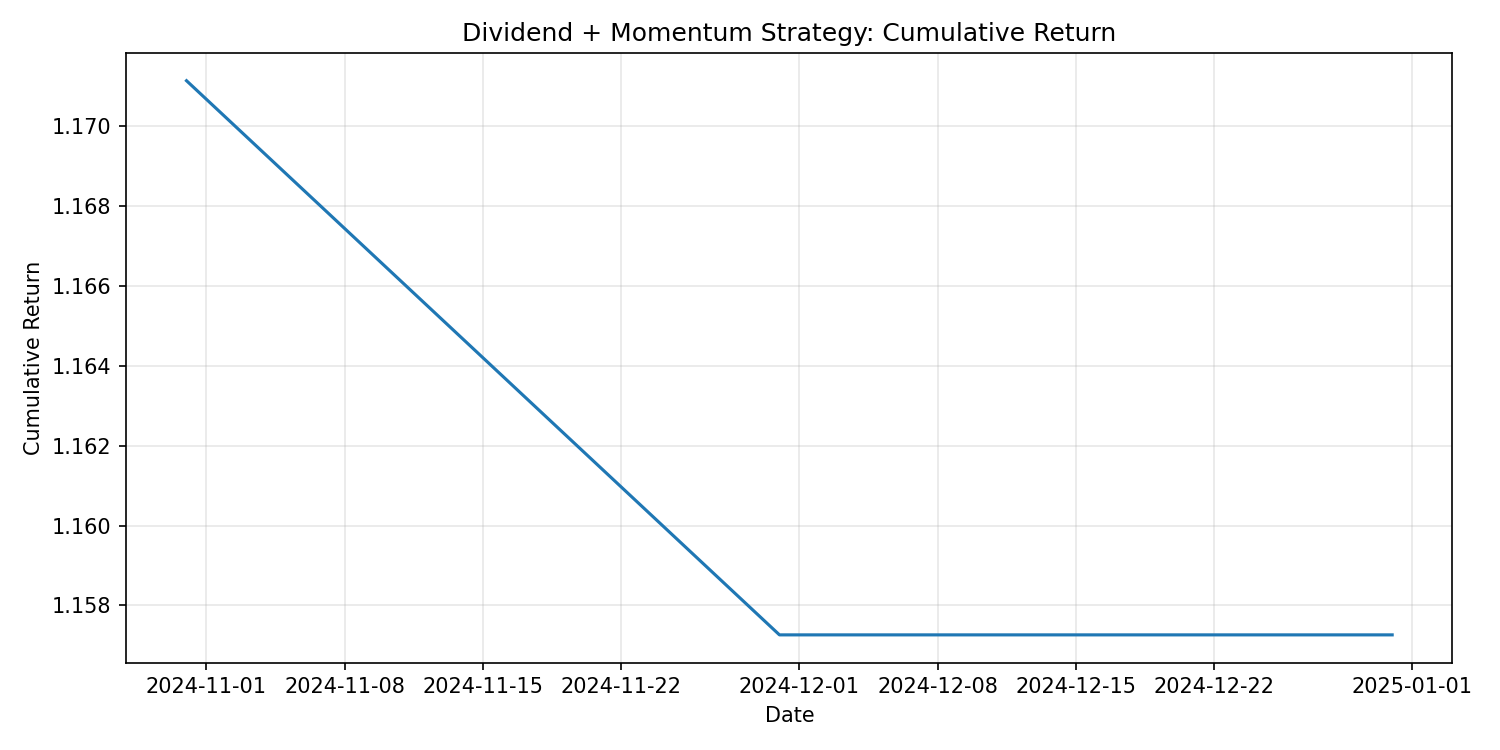

## Latest Period Signal Scatter Plot

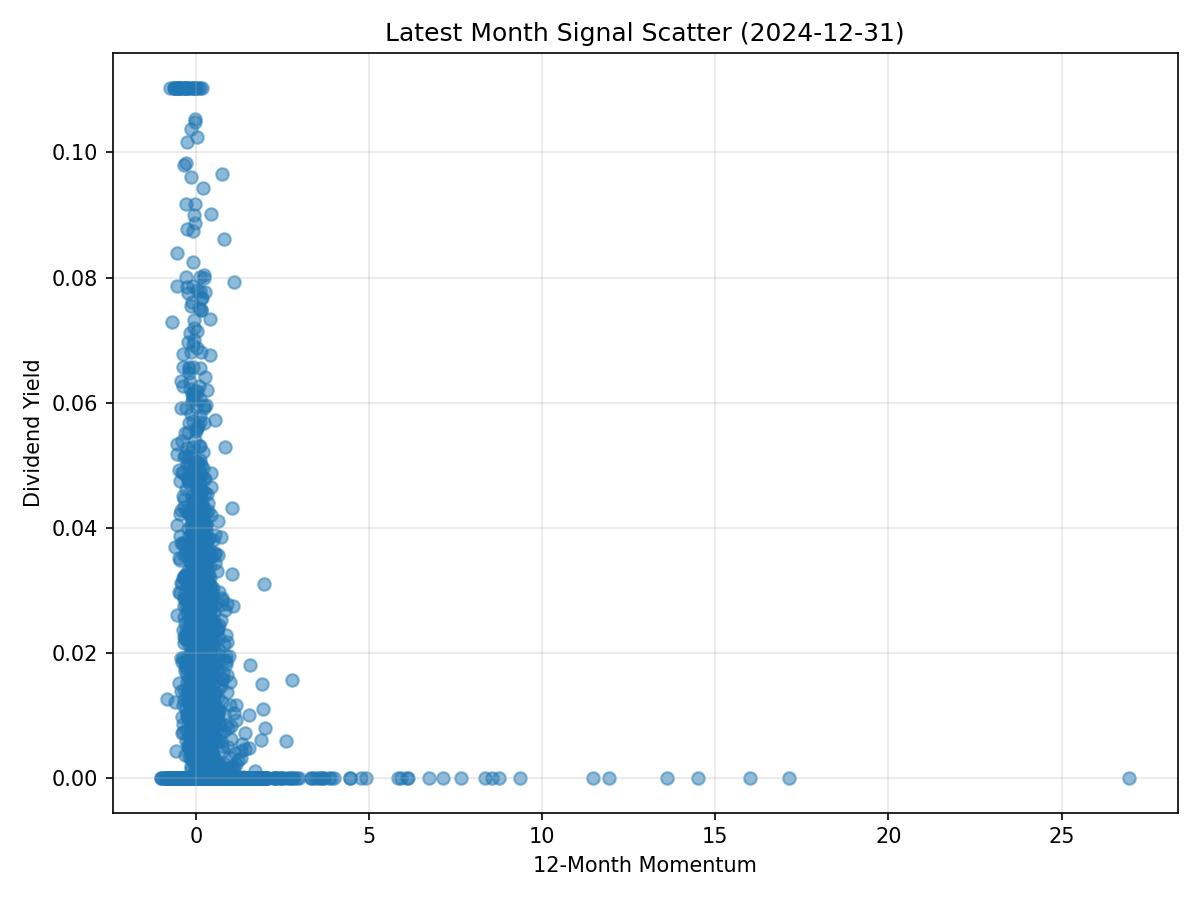

In [51]:
notebook_args = {
    "start_date": "2024-01-01",
    "end_date": "2024-12-31",
    "top_n": 10,
    "out_dir": "output_teaching"
 }
main()